<a href="https://colab.research.google.com/github/PradeepK-eng/Google-Colab-Files/blob/main/Engineering_failure_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Engineering Failure Prediction Theorems - Comprehensive Analysis
## With Data Ranges, Covariance Analysis, and Trend Visualization

**Author:** Engineering Analysis System  
**Date:** February 2026  
**Purpose:** Industrial failure prediction using established engineering theorems

### References:
- Griffith, A. A. (1921). "The Phenomena of Rupture and Flow in Solids"
- Irwin, G. R. (1957). "Analysis of Stresses and Strains Near the End of a Crack"
- Paris, P., & Erdogan, F. (1963). "A Critical Analysis of Crack Propagation Laws"
- ASME Boiler and Pressure Vessel Code
- AASHTO LRFD Bridge Design Specifications

## 1. Setup and Imports

In [ ]:
# Install required packages (uncomment if needed)
# !pip install numpy pandas matplotlib seaborn scipy plotly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All packages imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All packages imported successfully
NumPy version: 2.0.2
Pandas version: 2.2.2


## 2. Data Generation with Statistical Ranges

We'll create realistic industrial datasets with proper statistical distributions and covariance structures.

In [ ]:
class IndustrialDataGenerator:
    """
    Generate realistic industrial data with statistical distributions
    and covariance structures.
    """

    @staticmethod
    def generate_material_properties(n_samples=1000):
        """
        Generate correlated material property datasets.

        Returns:
            DataFrame with material properties including covariance
        """
        # Define means and standard deviations
        mean_E = 200e9  # Elastic modulus (Pa)
        std_E = 20e9

        mean_yield = 250e6  # Yield strength (Pa)
        std_yield = 25e6

        mean_K_IC = 50e6  # Fracture toughness (Pa·m^0.5)
        std_K_IC = 5e6

        # Create covariance matrix (materials with higher E tend to have higher strength)
        cov_matrix = np.array([
            [std_E**2, 0.6*std_E*std_yield, 0.4*std_E*std_K_IC],
            [0.6*std_E*std_yield, std_yield**2, 0.5*std_yield*std_K_IC],
            [0.4*std_E*std_K_IC, 0.5*std_yield*std_K_IC, std_K_IC**2]
        ])

        # Generate multivariate normal distribution
        data = np.random.multivariate_normal(
            [mean_E, mean_yield, mean_K_IC],
            cov_matrix,
            n_samples
        )

        df = pd.DataFrame(data, columns=['E_modulus_Pa', 'Yield_Strength_Pa', 'K_IC_Pa_m05'])

        # Add derived properties
        df['Poisson_Ratio'] = np.random.normal(0.3, 0.02, n_samples)
        df['Surface_Energy_J_m2'] = np.random.gamma(2, 0.5, n_samples)
        df['Material_ID'] = range(1, n_samples + 1)

        return df

    @staticmethod
    def generate_crack_data(n_samples=500):
        """
        Generate crack propagation data for fatigue analysis.
        """
        # Initial crack sizes (log-normal distribution)
        initial_cracks = np.random.lognormal(np.log(50e-6), 0.5, n_samples)

        # Stress ranges
        stress_ranges = np.random.gamma(20, 5, n_samples)  # MPa

        # Paris law constants (with some variation)
        m_values = np.random.normal(3.0, 0.2, n_samples)
        A_values = np.random.lognormal(np.log(4e-12), 0.3, n_samples)

        df = pd.DataFrame({
            'Initial_Crack_m': initial_cracks,
            'Stress_Range_MPa': stress_ranges,
            'Paris_m': m_values,
            'Paris_A': A_values,
            'Sample_ID': range(1, n_samples + 1)
        })

        return df

    @staticmethod
    def generate_pressure_vessel_data(n_samples=300):
        """
        Generate pressure vessel inspection data.
        """
        # Vessel dimensions
        diameters = np.random.uniform(0.5, 3.0, n_samples)  # meters
        thicknesses = np.random.uniform(0.01, 0.15, n_samples)  # meters

        # Operating pressures (correlated with diameter)
        pressures = 5 + 10 * (diameters / 3.0) + np.random.normal(0, 2, n_samples)
        pressures = np.maximum(pressures, 1.0)  # Minimum 1 MPa

        df = pd.DataFrame({
            'Diameter_m': diameters,
            'Thickness_m': thicknesses,
            'Pressure_MPa': pressures,
            'Vessel_ID': range(1, n_samples + 1)
        })

        return df

# Generate datasets
print("Generating industrial datasets...")
material_data = IndustrialDataGenerator.generate_material_properties(1000)
crack_data = IndustrialDataGenerator.generate_crack_data(500)
vessel_data = IndustrialDataGenerator.generate_pressure_vessel_data(300)

print(f"\n✓ Material properties dataset: {material_data.shape[0]} samples")
print(f"✓ Crack propagation dataset: {crack_data.shape[0]} samples")
print(f"✓ Pressure vessel dataset: {vessel_data.shape[0]} samples")

# Display sample data
print("\nSample Material Properties:")
display(material_data.head())

print("\nStatistical Summary:")
display(material_data.describe())

Generating industrial datasets...

✓ Material properties dataset: 1000 samples
✓ Crack propagation dataset: 500 samples
✓ Pressure vessel dataset: 300 samples

Sample Material Properties:


,E_modulus_Pa,Yield_Strength_Pa,K_IC_Pa_m05,Poisson_Ratio,Surface_Energy_J_m2,Material_ID
0,1.900657e+11,2.450795e+08,5.199763e+07,0.261844,0.390985,1
1,1.695394e+11,2.319216e+08,4.635637e+07,0.282792,0.813353,2
2,1.684158e+11,2.111357e+08,4.353770e+07,0.291728,0.225782,3
3,1.891488e+11,2.512971e+08,4.772225e+07,0.337754,1.277341,4
4,1.951607e+11,2.852546e+08,4.543418e+07,0.311131,0.556219,5



Statistical Summary:


,E_modulus_Pa,Yield_Strength_Pa,K_IC_Pa_m05,Poisson_Ratio,Surface_Energy_J_m2,Material_ID
count,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,1.988998e+11,2.492772e+08,5.009994e+07,0.299626,0.966748,500.500000
std,1.940425e+10,2.431899e+07,4.865411e+06,0.020543,0.665427,288.819436
min,1.214752e+11,1.576571e+08,3.601669e+07,0.241411,0.015149,1.000000
25%,1.867131e+11,2.325998e+08,4.698318e+07,0.285252,0.488899,250.750000
50%,1.988634e+11,2.502417e+08,5.001461e+07,0.300004,0.810583,500.500000
75%,2.116870e+11,2.655616e+08,5.327744e+07,0.313339,1.313574,750.250000
max,2.588078e+11,3.262003e+08,6.571470e+07,0.364862,4.815119,1000.000000


## 3. Covariance Analysis

Understanding the relationships between material properties is crucial for failure prediction.

Covariance Matrix:


,E_modulus_Pa,Yield_Strength_Pa,K_IC_Pa_m05
E_modulus_Pa,3.765248e+20,2.638877e+17,3.781693e+16
Yield_Strength_Pa,2.638877e+17,5.914134e+14,5.674810e+13
K_IC_Pa_m05,3.781693e+16,5.674810e+13,2.367223e+13



Correlation Matrix:


,E_modulus_Pa,Yield_Strength_Pa,K_IC_Pa_m05
E_modulus_Pa,1.000000,0.559212,0.400562
Yield_Strength_Pa,0.559212,1.000000,0.479608
K_IC_Pa_m05,0.400562,0.479608,1.000000


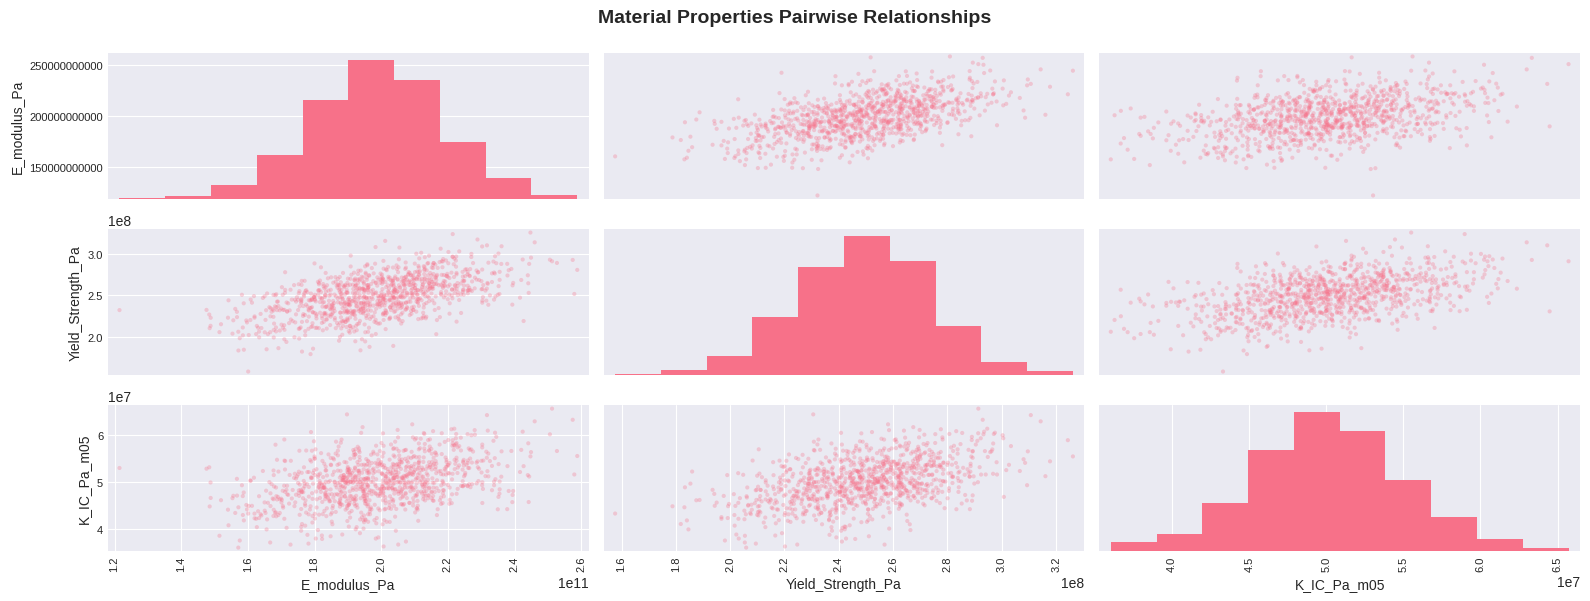

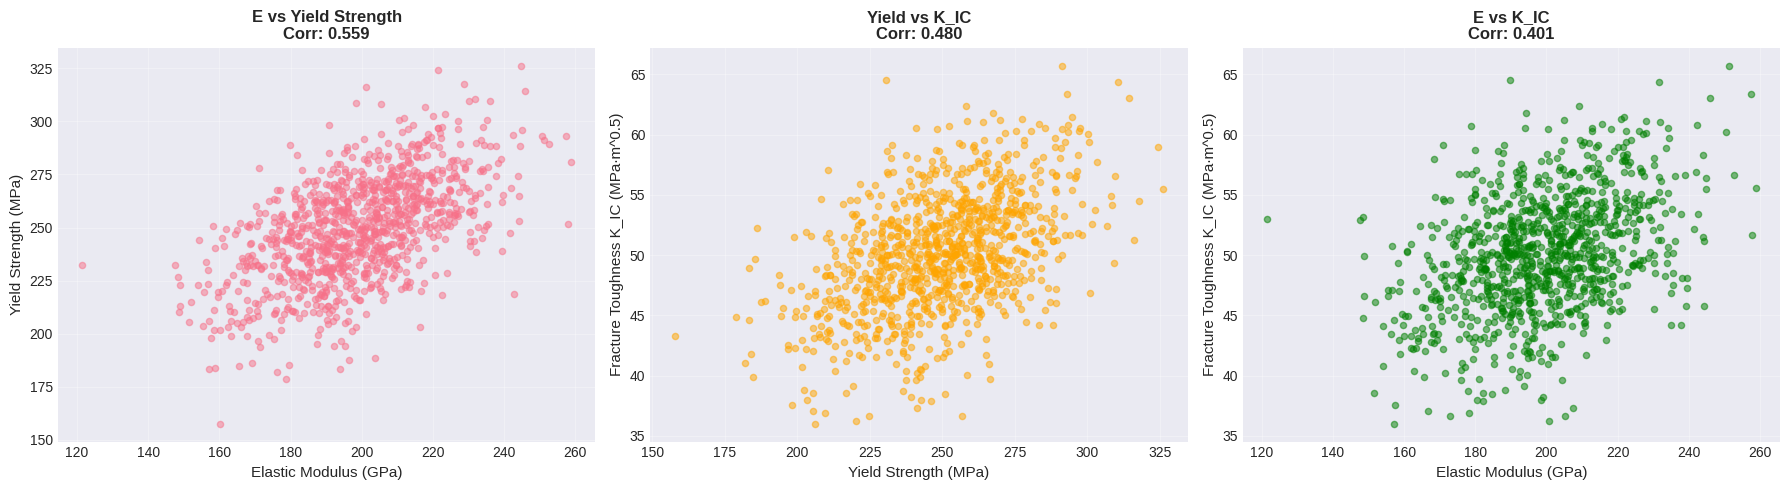

In [ ]:
# Calculate covariance matrix
cov_matrix = material_data[['E_modulus_Pa', 'Yield_Strength_Pa', 'K_IC_Pa_m05']].cov()
corr_matrix = material_data[['E_modulus_Pa', 'Yield_Strength_Pa', 'K_IC_Pa_m05']].corr()

print("Covariance Matrix:")
display(cov_matrix)

print("\nCorrelation Matrix:")
display(corr_matrix)

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of correlation
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Material Property Correlation Matrix', fontsize=14, fontweight='bold')

# Pairplot style visualization
from pandas.plotting import scatter_matrix
scatter_matrix(material_data[['E_modulus_Pa', 'Yield_Strength_Pa', 'K_IC_Pa_m05']],
               alpha=0.3, figsize=(10, 10), diagonal='hist', ax=axes[1])
plt.suptitle('Material Properties Pairwise Relationships', fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

# Additional covariance visualization
fig = plt.figure(figsize=(18, 5))

# E vs Yield Strength
ax1 = plt.subplot(131)
plt.scatter(material_data['E_modulus_Pa']/1e9, material_data['Yield_Strength_Pa']/1e6,
            alpha=0.5, s=20)
plt.xlabel('Elastic Modulus (GPa)', fontsize=11)
plt.ylabel('Yield Strength (MPa)', fontsize=11)
plt.title(f'E vs Yield Strength\nCorr: {corr_matrix.iloc[0,1]:.3f}', fontweight='bold')
plt.grid(True, alpha=0.3)

# Yield Strength vs K_IC
ax2 = plt.subplot(132)
plt.scatter(material_data['Yield_Strength_Pa']/1e6, material_data['K_IC_Pa_m05']/1e6,
            alpha=0.5, s=20, color='orange')
plt.xlabel('Yield Strength (MPa)', fontsize=11)
plt.ylabel('Fracture Toughness K_IC (MPa·m^0.5)', fontsize=11)
plt.title(f'Yield vs K_IC\nCorr: {corr_matrix.iloc[1,2]:.3f}', fontweight='bold')
plt.grid(True, alpha=0.3)

# E vs K_IC
ax3 = plt.subplot(133)
plt.scatter(material_data['E_modulus_Pa']/1e9, material_data['K_IC_Pa_m05']/1e6,
            alpha=0.5, s=20, color='green')
plt.xlabel('Elastic Modulus (GPa)', fontsize=11)
plt.ylabel('Fracture Toughness K_IC (MPa·m^0.5)', fontsize=11)
plt.title(f'E vs K_IC\nCorr: {corr_matrix.iloc[0,2]:.3f}', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Griffith Crack Theory - Analysis and Visualization

**Description:**
Griffith proposed that fracture in brittle materials occurs when the energy released from crack growth equals the energy required to create new fracture surface area. The critical stress depends inversely on the square root of crack length.

Source:
🎓 Griffith’s energy-balance fracture criterion – Wikipedia: https://en.wikipedia.org/wiki/Fracture_mechanics

**Formula:**

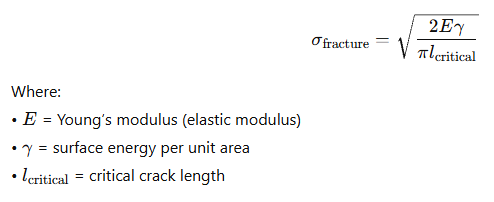

Industrial Example:
In glass manufacturing, a 2 µm crack with 𝐸=80.1GPa and surface energy = 0.2 J/m² predicts fracture stress of ~74 MPa using Griffith’s criterion. Ref: https://www.sciencedirect.com/topics/engineering/griffith-criterion?utm_source=chatgpt.com

Analyzing Griffith Crack Theory across material ranges...

✓ Generated 5000 data points
  Crack size range: 0.0100 - 10.00 mm
  Strength range: 0.5 - 181.2 MPa


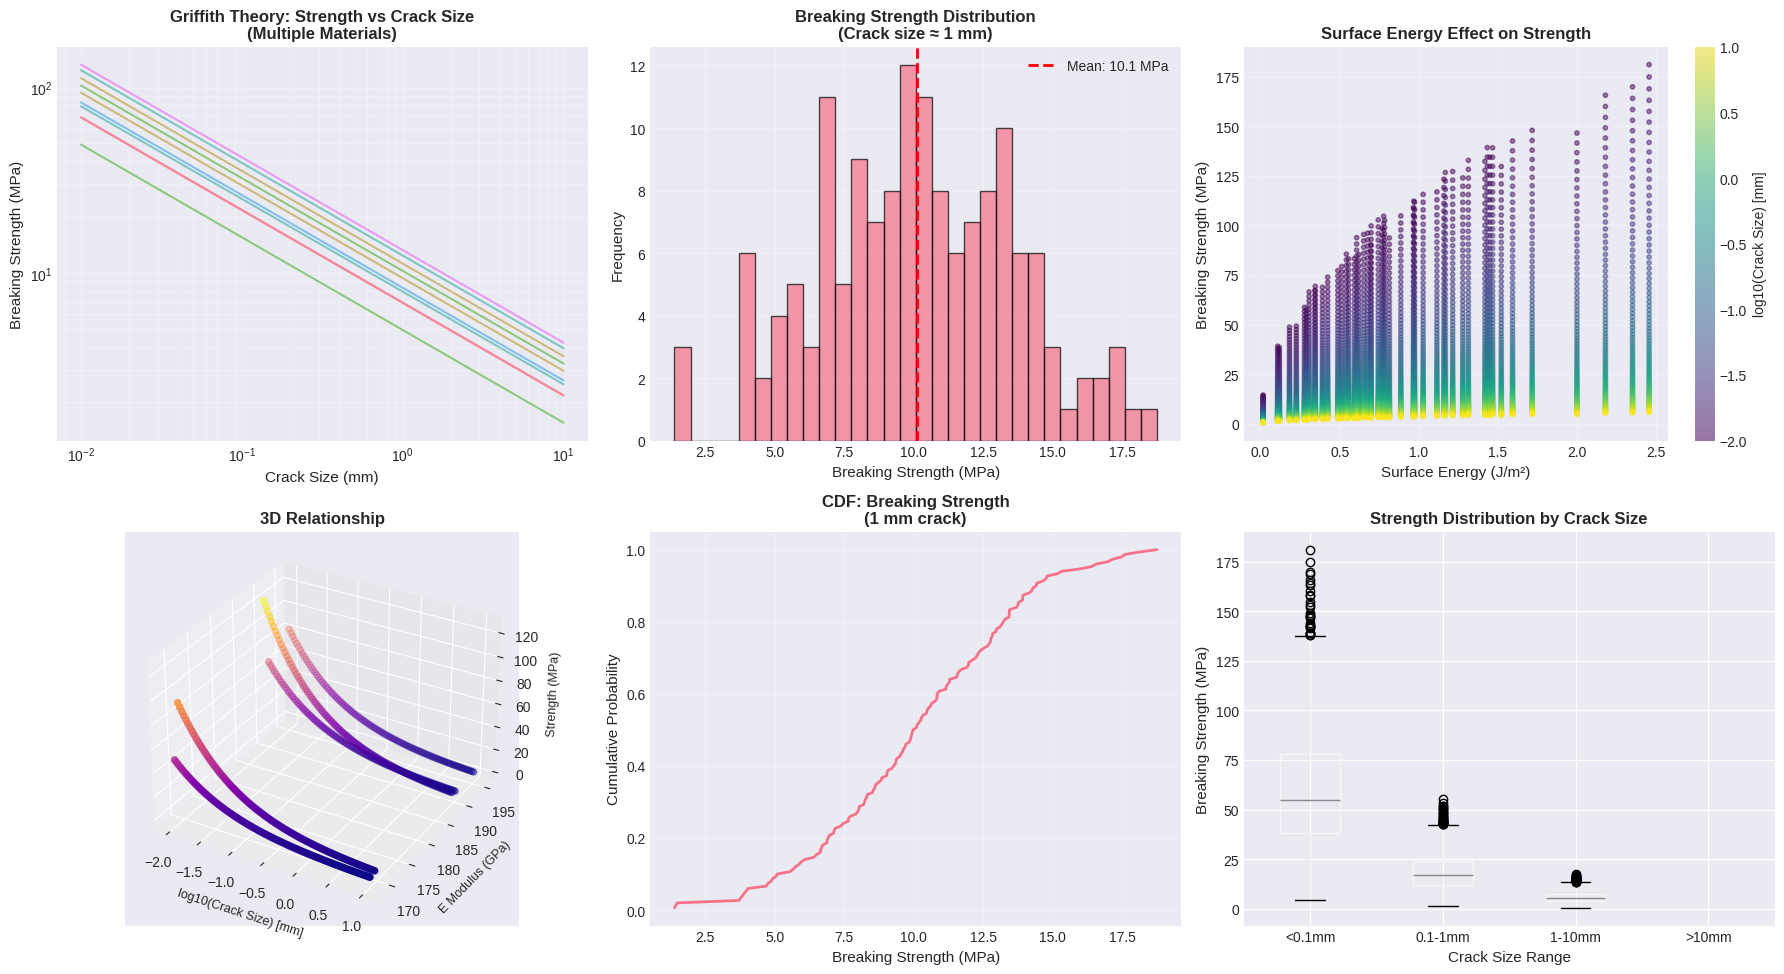


GRIFFITH THEORY - STATISTICAL SUMMARY

Breaking Strength Statistics (1 mm crack):
  Mean: 10.12 MPa
  Std Dev: 3.59 MPa
  Min: 1.39 MPa
  Max: 18.76 MPa
  95% Confidence: [3.75, 17.25] MPa


In [ ]:
class GriffithAnalysis:
    """
    Griffith Crack Theory Analysis with data ranges and visualization.
    """

    @staticmethod
    def breaking_strength(gamma_s, E, a, beta=1.0):
        """Calculate breaking strength."""
        return np.sqrt((2 * gamma_s * E) / (np.pi * beta * a))

    @staticmethod
    def analyze_sensitivity(material_data):
        """
        Perform sensitivity analysis across material property ranges.
        """
        # Create crack size range
        crack_sizes = np.logspace(-5, -2, 100)  # 10 μm to 10 mm

        # Calculate breaking strength for different materials
        results = []

        for idx in range(min(50, len(material_data))):
            E = material_data.iloc[idx]['E_modulus_Pa']
            gamma_s = material_data.iloc[idx]['Surface_Energy_J_m2']

            strengths = GriffithAnalysis.breaking_strength(gamma_s, E, crack_sizes)

            for i, a in enumerate(crack_sizes):
                results.append({
                    'Material_ID': idx,
                    'Crack_Size_m': a,
                    'Crack_Size_mm': a * 1000,
                    'Breaking_Strength_MPa': strengths[i] / 1e6,
                    'E_GPa': E / 1e9,
                    'Surface_Energy': gamma_s
                })

        return pd.DataFrame(results)

# Perform analysis
print("Analyzing Griffith Crack Theory across material ranges...")
griffith_results = GriffithAnalysis.analyze_sensitivity(material_data)

print(f"\n✓ Generated {len(griffith_results)} data points")
print(f"  Crack size range: {griffith_results['Crack_Size_mm'].min():.4f} - {griffith_results['Crack_Size_mm'].max():.2f} mm")
print(f"  Strength range: {griffith_results['Breaking_Strength_MPa'].min():.1f} - {griffith_results['Breaking_Strength_MPa'].max():.1f} MPa")

# Visualization
fig = plt.figure(figsize=(18, 10))

# Plot 1: Breaking strength vs crack size (multiple materials)
ax1 = plt.subplot(2, 3, 1)
for mat_id in griffith_results['Material_ID'].unique()[:10]:
    data = griffith_results[griffith_results['Material_ID'] == mat_id]
    plt.loglog(data['Crack_Size_mm'], data['Breaking_Strength_MPa'], alpha=0.6, linewidth=1.5)

plt.xlabel('Crack Size (mm)', fontsize=11)
plt.ylabel('Breaking Strength (MPa)', fontsize=11)
plt.title('Griffith Theory: Strength vs Crack Size\n(Multiple Materials)', fontweight='bold')
plt.grid(True, alpha=0.3, which='both')

# Plot 2: Statistical distribution of breaking strength at specific crack size
ax2 = plt.subplot(2, 3, 2)
specific_crack = griffith_results[griffith_results['Crack_Size_mm'].between(0.9, 1.1)]
plt.hist(specific_crack['Breaking_Strength_MPa'], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(specific_crack['Breaking_Strength_MPa'].mean(), color='red',
            linestyle='--', linewidth=2, label=f'Mean: {specific_crack["Breaking_Strength_MPa"].mean():.1f} MPa')
plt.xlabel('Breaking Strength (MPa)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Breaking Strength Distribution\n(Crack size ≈ 1 mm)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Effect of surface energy
ax3 = plt.subplot(2, 3, 3)
scatter = plt.scatter(griffith_results['Surface_Energy'],
                     griffith_results['Breaking_Strength_MPa'],
                     c=np.log10(griffith_results['Crack_Size_mm']),
                     cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='log10(Crack Size) [mm]')
plt.xlabel('Surface Energy (J/m²)', fontsize=11)
plt.ylabel('Breaking Strength (MPa)', fontsize=11)
plt.title('Surface Energy Effect on Strength', fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 4: 3D surface plot (using specific materials)
ax4 = plt.subplot(2, 3, 4, projection='3d')
sample_data = griffith_results[griffith_results['Material_ID'] < 5]
ax4.scatter(np.log10(sample_data['Crack_Size_mm']),
           sample_data['E_GPa'],
           sample_data['Breaking_Strength_MPa'],
           c=sample_data['Breaking_Strength_MPa'], cmap='plasma', s=20)
ax4.set_xlabel('log10(Crack Size) [mm]', fontsize=9)
ax4.set_ylabel('E Modulus (GPa)', fontsize=9)
ax4.set_zlabel('Strength (MPa)', fontsize=9)
ax4.set_title('3D Relationship', fontweight='bold')

# Plot 5: Cumulative distribution
ax5 = plt.subplot(2, 3, 5)
specific_crack_sorted = np.sort(specific_crack['Breaking_Strength_MPa'])
cumulative = np.arange(1, len(specific_crack_sorted) + 1) / len(specific_crack_sorted)
plt.plot(specific_crack_sorted, cumulative, linewidth=2)
plt.xlabel('Breaking Strength (MPa)', fontsize=11)
plt.ylabel('Cumulative Probability', fontsize=11)
plt.title('CDF: Breaking Strength\n(1 mm crack)', fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 6: Box plot by crack size ranges
ax6 = plt.subplot(2, 3, 6)
griffith_results['Crack_Range'] = pd.cut(griffith_results['Crack_Size_mm'],
                                          bins=[0, 0.1, 1, 10, 100],
                                          labels=['<0.1mm', '0.1-1mm', '1-10mm', '>10mm'])
griffith_results.boxplot(column='Breaking_Strength_MPa', by='Crack_Range', ax=ax6)
plt.xlabel('Crack Size Range', fontsize=11)
plt.ylabel('Breaking Strength (MPa)', fontsize=11)
plt.title('Strength Distribution by Crack Size', fontweight='bold')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*60)
print("GRIFFITH THEORY - STATISTICAL SUMMARY")
print("="*60)
print("\nBreaking Strength Statistics (1 mm crack):")
print(f"  Mean: {specific_crack['Breaking_Strength_MPa'].mean():.2f} MPa")
print(f"  Std Dev: {specific_crack['Breaking_Strength_MPa'].std():.2f} MPa")
print(f"  Min: {specific_crack['Breaking_Strength_MPa'].min():.2f} MPa")
print(f"  Max: {specific_crack['Breaking_Strength_MPa'].max():.2f} MPa")
print(f"  95% Confidence: [{specific_crack['Breaking_Strength_MPa'].quantile(0.025):.2f}, {specific_crack['Breaking_Strength_MPa'].quantile(0.975):.2f}] MPa")

## 5. Irwin Stress Intensity Factor - Analysis

**Description:**
Irwin extended Griffith by focusing on the stress field near a crack tip and defined the stress intensity factor (SIF), 𝐾𝐼𝑐, which predicts failure when it reaches the material’s fracture toughness 𝐾𝐼𝑐.

**Formula:**
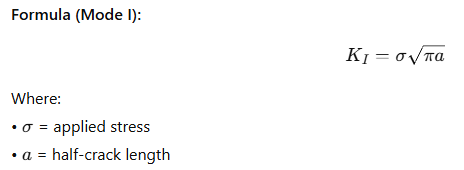


Industrial Example:
In steel bridges, if a tie has a crack length of 24 mm and fracture toughness
𝐾𝐼𝑐=55 MPa·√m, Irwin’s equation can be used to estimate the critical stress that will drive failure. (Example provided in problem context.)

Source:
📘 Stress Intensity Factor concept – Wikipedia: https://en.wikipedia.org/wiki/Stress_intensity_factor


Analyzing Irwin Stress Intensity Factor...

✓ Generated 5000 scenarios
  Crack length range: 5.0 - 50.0 mm
  Force capacity range: 427.9 - 2012.0 kN


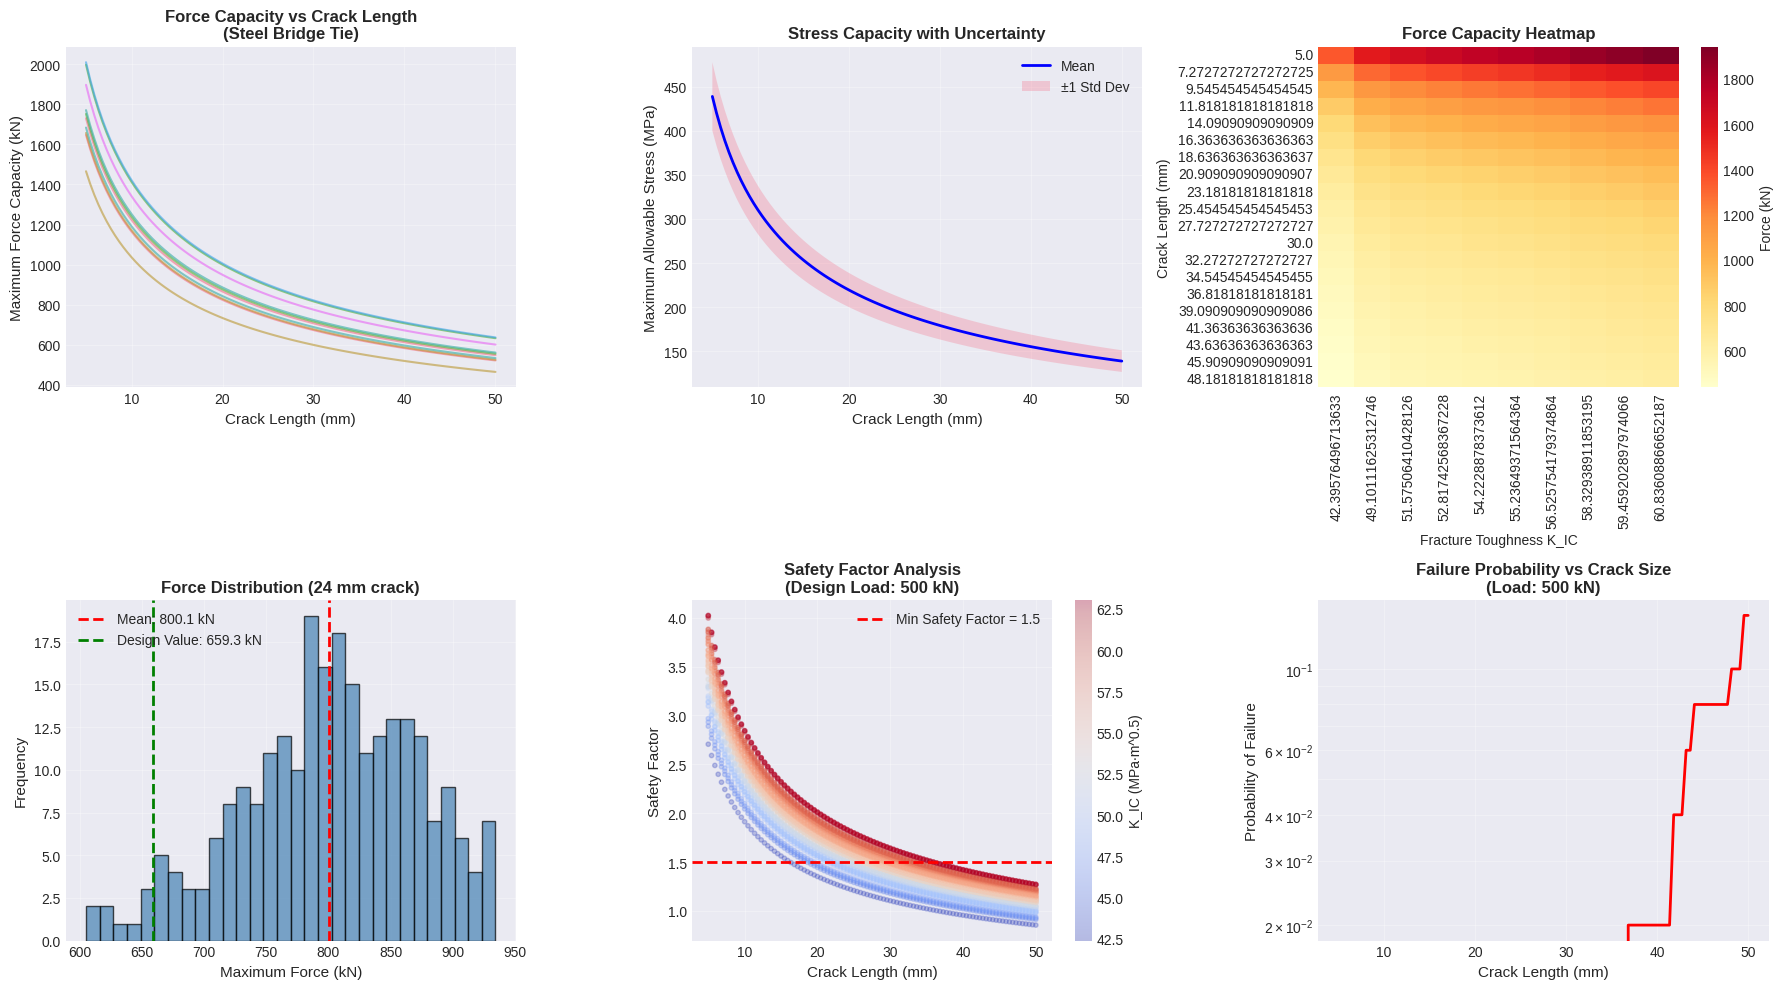


IRWIN THEORY - BRIDGE TIE ANALYSIS

For 24 mm crack (as per industrial example):
  Mean Force Capacity: 800.13 kN
  Std Dev: 70.97 kN
  95% Lower Bound: 668.72 kN
  Design Reference: 659.28 kN (from literature)


In [ ]:
class IrwinAnalysis:
    """
    Irwin Stress Intensity Factor analysis with data arrays.
    """

    @staticmethod
    def stress_intensity_factor(sigma, a):
        """Calculate K_I."""
        return sigma * np.sqrt(np.pi * a)

    @staticmethod
    def analyze_bridge_tie_scenarios():
        """
        Analyze steel tie scenarios with varying crack sizes and loads.
        """
        # Parameters
        K_IC_values = np.random.normal(55, 5, 200)  # MPa·m^0.5, variability in material
        crack_lengths = np.linspace(5, 50, 100)  # mm

        # Cross-section
        width = 0.2  # m
        depth = 0.02  # m
        area = width * depth  # m²

        results = []

        for K_IC in K_IC_values[:50]:  # Use subset for speed
            for crack_length in crack_lengths:
                a = crack_length / 1000  # Convert to m

                # Maximum allowable stress
                sigma_max = K_IC / np.sqrt(np.pi * a)

                # Maximum force
                force_max = sigma_max * area * 1000  # kN

                results.append({
                    'K_IC_MPa_m05': K_IC,
                    'Crack_Length_mm': crack_length,
                    'Max_Stress_MPa': sigma_max,
                    'Max_Force_kN': force_max
                })

        return pd.DataFrame(results)

# Perform analysis
print("Analyzing Irwin Stress Intensity Factor...")
irwin_results = IrwinAnalysis.analyze_bridge_tie_scenarios()

print(f"\n✓ Generated {len(irwin_results)} scenarios")
print(f"  Crack length range: {irwin_results['Crack_Length_mm'].min():.1f} - {irwin_results['Crack_Length_mm'].max():.1f} mm")
print(f"  Force capacity range: {irwin_results['Max_Force_kN'].min():.1f} - {irwin_results['Max_Force_kN'].max():.1f} kN")

# Visualization
fig = plt.figure(figsize=(18, 10))

# Plot 1: Force capacity vs crack length
ax1 = plt.subplot(2, 3, 1)
for K_IC in irwin_results['K_IC_MPa_m05'].unique()[:10]:
    data = irwin_results[irwin_results['K_IC_MPa_m05'] == K_IC]
    plt.plot(data['Crack_Length_mm'], data['Max_Force_kN'], alpha=0.6, linewidth=1.5)

plt.xlabel('Crack Length (mm)', fontsize=11)
plt.ylabel('Maximum Force Capacity (kN)', fontsize=11)
plt.title('Force Capacity vs Crack Length\n(Steel Bridge Tie)', fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 2: Stress vs crack length
ax2 = plt.subplot(2, 3, 2)
mean_by_crack = irwin_results.groupby('Crack_Length_mm')['Max_Stress_MPa'].agg(['mean', 'std'])
plt.plot(mean_by_crack.index, mean_by_crack['mean'], 'b-', linewidth=2, label='Mean')
plt.fill_between(mean_by_crack.index,
                 mean_by_crack['mean'] - mean_by_crack['std'],
                 mean_by_crack['mean'] + mean_by_crack['std'],
                 alpha=0.3, label='±1 Std Dev')
plt.xlabel('Crack Length (mm)', fontsize=11)
plt.ylabel('Maximum Allowable Stress (MPa)', fontsize=11)
plt.title('Stress Capacity with Uncertainty', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap of K_IC effect
ax3 = plt.subplot(2, 3, 3)
pivot_data = irwin_results.pivot_table(
    values='Max_Force_kN',
    index='Crack_Length_mm',
    columns='K_IC_MPa_m05',
    aggfunc='mean'
)
sns.heatmap(pivot_data.iloc[::5, ::5], cmap='YlOrRd', cbar_kws={'label': 'Force (kN)'}, ax=ax3)
ax3.set_xlabel('Fracture Toughness K_IC', fontsize=10)
ax3.set_ylabel('Crack Length (mm)', fontsize=10)
ax3.set_title('Force Capacity Heatmap', fontweight='bold')

# Plot 4: Distribution at critical crack length (24 mm)
ax4 = plt.subplot(2, 3, 4)
critical_crack_data = irwin_results[irwin_results['Crack_Length_mm'].between(23, 25)]
plt.hist(critical_crack_data['Max_Force_kN'], bins=30, alpha=0.7, edgecolor='black', color='steelblue')
mean_force = critical_crack_data['Max_Force_kN'].mean()
plt.axvline(mean_force, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_force:.1f} kN')
plt.axvline(659.282, color='green', linestyle='--', linewidth=2,
            label='Design Value: 659.3 kN')
plt.xlabel('Maximum Force (kN)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Force Distribution (24 mm crack)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Safety factor analysis
ax5 = plt.subplot(2, 3, 5)
design_load = 500  # kN (example design load)
irwin_results['Safety_Factor'] = irwin_results['Max_Force_kN'] / design_load
plt.scatter(irwin_results['Crack_Length_mm'], irwin_results['Safety_Factor'],
           alpha=0.3, s=10, c=irwin_results['K_IC_MPa_m05'], cmap='coolwarm')
plt.axhline(y=1.5, color='red', linestyle='--', linewidth=2, label='Min Safety Factor = 1.5')
plt.colorbar(label='K_IC (MPa·m^0.5)')
plt.xlabel('Crack Length (mm)', fontsize=11)
plt.ylabel('Safety Factor', fontsize=11)
plt.title(f'Safety Factor Analysis\n(Design Load: {design_load} kN)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Probability of failure
ax6 = plt.subplot(2, 3, 6)
# Calculate probability that force < design load for each crack size
prob_failure = []
crack_lengths_unique = sorted(irwin_results['Crack_Length_mm'].unique())
for crack_len in crack_lengths_unique:
    subset = irwin_results[irwin_results['Crack_Length_mm'] == crack_len]
    prob = (subset['Max_Force_kN'] < design_load).sum() / len(subset)
    prob_failure.append(prob)

plt.semilogy(crack_lengths_unique, prob_failure, 'r-', linewidth=2)
plt.xlabel('Crack Length (mm)', fontsize=11)
plt.ylabel('Probability of Failure', fontsize=11)
plt.title(f'Failure Probability vs Crack Size\n(Load: {design_load} kN)', fontweight='bold')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*60)
print("IRWIN THEORY - BRIDGE TIE ANALYSIS")
print("="*60)
print(f"\nFor 24 mm crack (as per industrial example):")
print(f"  Mean Force Capacity: {critical_crack_data['Max_Force_kN'].mean():.2f} kN")
print(f"  Std Dev: {critical_crack_data['Max_Force_kN'].std():.2f} kN")
print(f"  95% Lower Bound: {critical_crack_data['Max_Force_kN'].quantile(0.05):.2f} kN")
print(f"  Design Reference: 659.28 kN (from literature)")

## 6. Paris-Erdogan Law - Fatigue Crack Growth

**Description:**
This empirical law predicts how crack length increases per load cycle in fatigue, depending on stress intensity range Δ𝐾.

**Formula:**
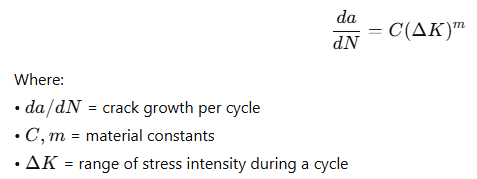

Industrial Example:
Used for evaluating life expectancy of rotating engine discs, turbine blades, and aircraft components under cyclic stresses.

Source:
📘 Paris’ law overview – Wikipedia: https://en.wikipedia.org/wiki/Paris%27_law

Analyzing Paris-Erdogan Fatigue Crack Growth...

✓ Maximum allowable stress for ≤5% growth: 20.00 MPa
  (Literature value: 10.4 MPa)


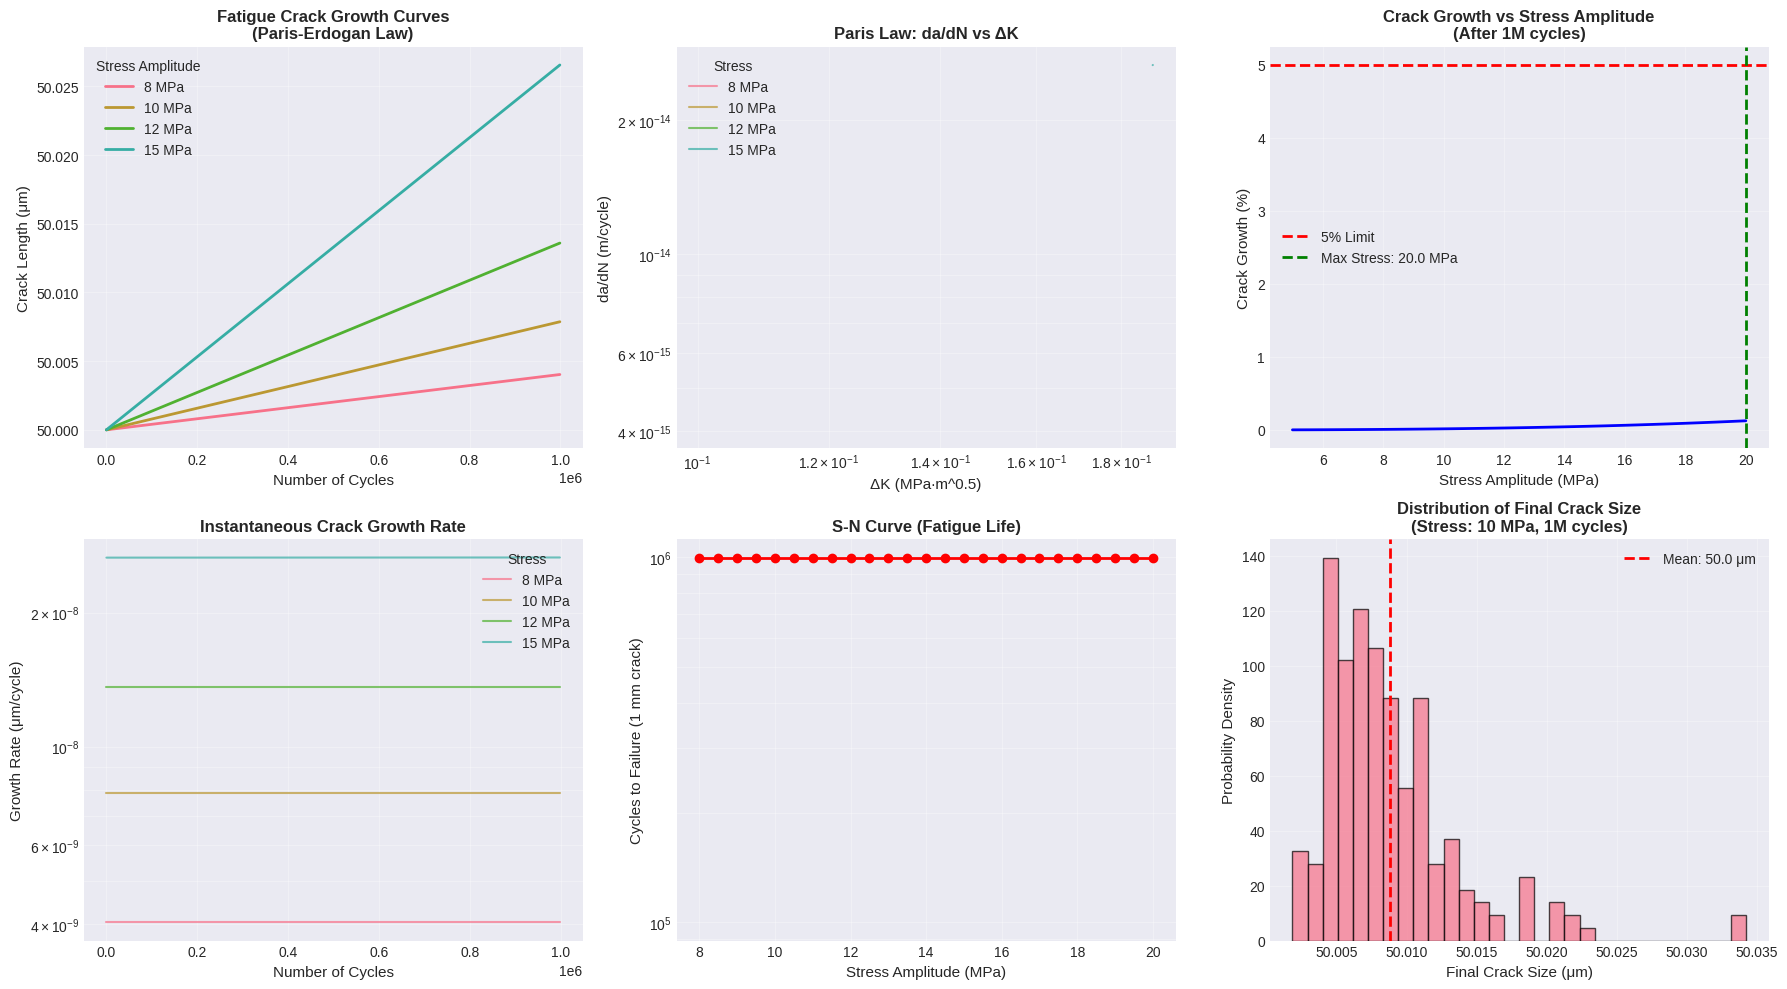


PARIS-ERDOGAN LAW - FATIGUE ANALYSIS

For Aero-Engine Disc (initial crack: 50 μm):
  Maximum allowable stress: 20.00 MPa
  To limit growth to ≤5% over 1M cycles

Final crack distribution (10 MPa, 1M cycles):
  Mean: 50.01 μm
  Std Dev: 0.00 μm
  Growth: 0.0%


In [ ]:
class ParisErdoganAnalysis:
    """
    Paris-Erdogan fatigue crack growth analysis.
    """

    @staticmethod
    def crack_growth_rate(delta_K, A, m):
        """Calculate da/dN."""
        return A * (delta_K ** m)

    @staticmethod
    def simulate_crack_growth(a_initial, delta_sigma, A, m, max_cycles=1000000):
        """
        Simulate crack growth over loading cycles.
        """
        cycles = [0]
        crack_lengths = [a_initial]

        a = a_initial
        N = 0

        while N < max_cycles and a < 0.01:  # Stop at 10 mm crack
            delta_K = delta_sigma * np.sqrt(np.pi * a)
            da_dN = A * (delta_K ** m)

            # Adaptive step size
            dN = min(1000, max(1, 0.01 * a / da_dN))

            a += da_dN * dN
            N += dN

            if len(cycles) < 1000:  # Limit data points
                cycles.append(N)
                crack_lengths.append(a)

        return np.array(cycles), np.array(crack_lengths)

    @staticmethod
    def analyze_aero_engine_scenarios():
        """
        Analyze aero-engine disc scenarios with varying parameters.
        """
        # Parameter ranges
        stress_amplitudes = np.linspace(5, 20, 30)  # MPa
        a_initial = 50e-6  # 50 μm
        A = 4e-12
        m = 3
        target_cycles = 1e6

        results = []

        for stress in stress_amplitudes:
            cycles, crack_lengths = ParisErdoganAnalysis.simulate_crack_growth(
                a_initial, stress, A, m, max_cycles=target_cycles
            )

            # Final crack size
            final_crack = crack_lengths[-1]
            growth_pct = ((final_crack - a_initial) / a_initial) * 100

            results.append({
                'Stress_Amplitude_MPa': stress,
                'Final_Crack_m': final_crack,
                'Growth_Percentage': growth_pct,
                'Cycles_to_Target': cycles[-1],
                'Meets_Criterion': growth_pct <= 5
            })

        return pd.DataFrame(results)

# Perform analysis
print("Analyzing Paris-Erdogan Fatigue Crack Growth...")
paris_results = ParisErdoganAnalysis.analyze_aero_engine_scenarios()

# Find maximum allowable stress for 5% growth
acceptable = paris_results[paris_results['Meets_Criterion']]
if len(acceptable) > 0:
    max_allowable_stress = acceptable['Stress_Amplitude_MPa'].max()
else:
    max_allowable_stress = paris_results['Stress_Amplitude_MPa'].min()

print(f"\n✓ Maximum allowable stress for ≤5% growth: {max_allowable_stress:.2f} MPa")
print(f"  (Literature value: 10.4 MPa)")

# Simulate detailed growth curves for visualization
stress_levels = [8, 10, 12, 15]  # MPa
growth_curves = {}

for stress in stress_levels:
    cycles, cracks = ParisErdoganAnalysis.simulate_crack_growth(
        50e-6, stress, 4e-12, 3, max_cycles=2e6
    )
    growth_curves[stress] = (cycles, cracks)

# Visualization
fig = plt.figure(figsize=(18, 10))

# Plot 1: Crack growth curves
ax1 = plt.subplot(2, 3, 1)
for stress, (cycles, cracks) in growth_curves.items():
    plt.plot(cycles, cracks * 1e6, linewidth=2, label=f'{stress} MPa')

plt.xlabel('Number of Cycles', fontsize=11)
plt.ylabel('Crack Length (μm)', fontsize=11)
plt.title('Fatigue Crack Growth Curves\n(Paris-Erdogan Law)', fontweight='bold')
plt.legend(title='Stress Amplitude')
plt.grid(True, alpha=0.3)

# Plot 2: Log-log plot (Paris law)
ax2 = plt.subplot(2, 3, 2)
for stress, (cycles, cracks) in growth_curves.items():
    # Calculate growth rate
    if len(cycles) > 1:
        da_dN = np.diff(cracks) / np.diff(cycles)
        delta_K = stress * np.sqrt(np.pi * cracks[:-1])
        valid = (da_dN > 0) & (delta_K > 0)
        plt.loglog(delta_K[valid], da_dN[valid], alpha=0.7, label=f'{stress} MPa')

plt.xlabel('ΔK (MPa·m^0.5)', fontsize=11)
plt.ylabel('da/dN (m/cycle)', fontsize=11)
plt.title('Paris Law: da/dN vs ΔK', fontweight='bold')
plt.legend(title='Stress')
plt.grid(True, alpha=0.3, which='both')

# Plot 3: Growth percentage vs stress
ax3 = plt.subplot(2, 3, 3)
plt.plot(paris_results['Stress_Amplitude_MPa'], paris_results['Growth_Percentage'],
         'b-', linewidth=2)
plt.axhline(y=5, color='red', linestyle='--', linewidth=2, label='5% Limit')
plt.axvline(x=max_allowable_stress, color='green', linestyle='--', linewidth=2,
           label=f'Max Stress: {max_allowable_stress:.1f} MPa')
plt.xlabel('Stress Amplitude (MPa)', fontsize=11)
plt.ylabel('Crack Growth (%)', fontsize=11)
plt.title('Crack Growth vs Stress Amplitude\n(After 1M cycles)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Crack growth rate over time
ax4 = plt.subplot(2, 3, 4)
for stress, (cycles, cracks) in growth_curves.items():
    if len(cycles) > 1:
        growth_rate = np.diff(cracks * 1e6) / np.diff(cycles)  # μm/cycle
        plt.semilogy(cycles[:-1], growth_rate, alpha=0.7, linewidth=1.5, label=f'{stress} MPa')

plt.xlabel('Number of Cycles', fontsize=11)
plt.ylabel('Growth Rate (μm/cycle)', fontsize=11)
plt.title('Instantaneous Crack Growth Rate', fontweight='bold')
plt.legend(title='Stress')
plt.grid(True, alpha=0.3, which='both')

# Plot 5: Life prediction - cycles to failure
ax5 = plt.subplot(2, 3, 5)
# Simulate to failure (crack = 1 mm)
stress_range_life = np.linspace(8, 20, 25)
cycles_to_failure = []

for stress in stress_range_life:
    cycles, cracks = ParisErdoganAnalysis.simulate_crack_growth(
        50e-6, stress, 4e-12, 3, max_cycles=1e8
    )
    # Find when crack reaches 1 mm
    failure_idx = np.where(cracks >= 1e-3)[0]
    if len(failure_idx) > 0:
        cycles_to_failure.append(cycles[failure_idx[0]])
    else:
        cycles_to_failure.append(cycles[-1])

plt.semilogy(stress_range_life, cycles_to_failure, 'ro-', linewidth=2, markersize=6)
plt.xlabel('Stress Amplitude (MPa)', fontsize=11)
plt.ylabel('Cycles to Failure (1 mm crack)', fontsize=11)
plt.title('S-N Curve (Fatigue Life)', fontweight='bold')
plt.grid(True, alpha=0.3, which='both')

# Plot 6: Probability density
ax6 = plt.subplot(2, 3, 6)
# Add uncertainty to Paris constants
np.random.seed(42)
n_simulations = 200
stress_test = 10  # MPa
final_cracks_dist = []

for _ in range(n_simulations):
    A_sample = np.random.lognormal(np.log(4e-12), 0.3)
    m_sample = np.random.normal(3, 0.2)
    cycles, cracks = ParisErdoganAnalysis.simulate_crack_growth(
        50e-6, stress_test, A_sample, m_sample, max_cycles=1e6
    )
    final_cracks_dist.append(cracks[-1] * 1e6)  # μm

plt.hist(final_cracks_dist, bins=30, alpha=0.7, edgecolor='black', density=True)
plt.xlabel('Final Crack Size (μm)', fontsize=11)
plt.ylabel('Probability Density', fontsize=11)
plt.title(f'Distribution of Final Crack Size\n(Stress: {stress_test} MPa, 1M cycles)', fontweight='bold')
plt.axvline(np.mean(final_cracks_dist), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {np.mean(final_cracks_dist):.1f} μm')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*60)
print("PARIS-ERDOGAN LAW - FATIGUE ANALYSIS")
print("="*60)
print(f"\nFor Aero-Engine Disc (initial crack: 50 μm):")
print(f"  Maximum allowable stress: {max_allowable_stress:.2f} MPa")
print(f"  To limit growth to ≤5% over 1M cycles")
print(f"\nFinal crack distribution (10 MPa, 1M cycles):")
print(f"  Mean: {np.mean(final_cracks_dist):.2f} μm")
print(f"  Std Dev: {np.std(final_cracks_dist):.2f} μm")
print(f"  Growth: {(np.mean(final_cracks_dist) - 50)/50 * 100:.1f}%")

## 7. Von Mises and Tresca - Failure Criteria Comparison

**Distortion Energy Theory (von Mises)**

**Description**:
Predicts yielding of ductile materials by equating distortion energy to energy under uniaxial tension. Widely used in pressure vessel design and metal forming.

**Formula:**

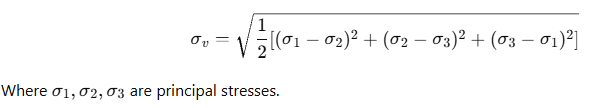

Industrial Example:
Design of cylindrical tanks under internal pressure to prevent yielding.

Note: von Mises criterion is widely used in FEM and design codes for ductile materials.


**Maximum Shearing Stress (Tresca Criterion)**

**Description:**
Predicts yielding when maximum shear stress reaches yield shear stress.

**Formula:**
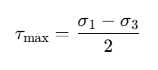


Industrial Example:
Shaft diameter design under combined bending and torsion to prevent plastic deformation.

Analyzing Failure Criteria (Von Mises vs Tresca)...

✓ Analyzed 200 pressure vessels
  Tresca is 15.4% higher on average (more conservative)


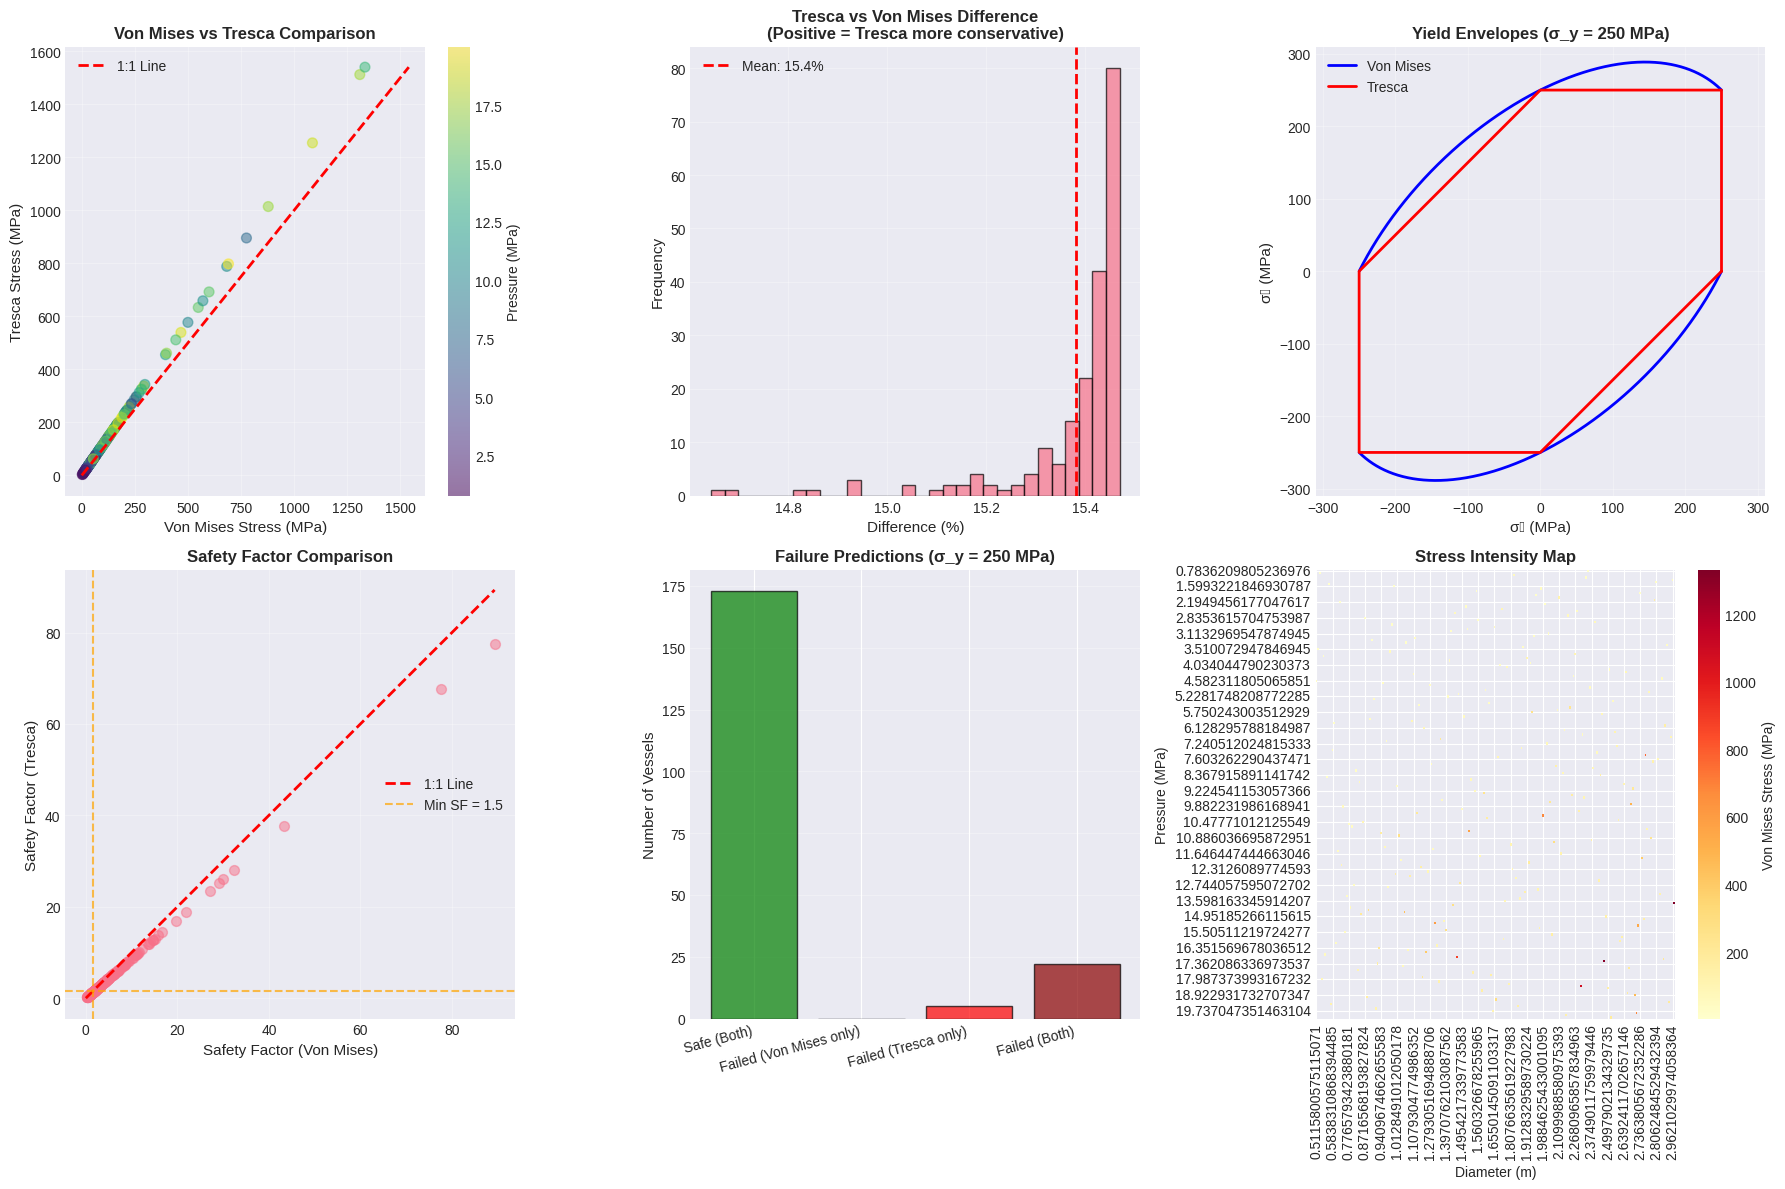


FAILURE CRITERIA COMPARISON

Von Mises Stress:
  Mean: 139.40 MPa
  Std Dev: 194.44 MPa

Tresca Stress:
  Mean: 160.92 MPa
  Std Dev: 224.53 MPa

Difference:
  Average: 15.38%
  Tresca is consistently more conservative

Predicted Failures (σ_y = 250 MPa):
  Von Mises: 22 vessels
  Tresca: 27 vessels


In [ ]:
class FailureCriteriaAnalysis:
    """
    Compare Von Mises and Tresca failure criteria.
    """

    @staticmethod
    def von_mises_stress(sigma1, sigma2, sigma3):
        """Calculate von Mises equivalent stress."""
        return np.sqrt(0.5 * ((sigma1 - sigma2)**2 +
                              (sigma2 - sigma3)**2 +
                              (sigma3 - sigma1)**2))

    @staticmethod
    def tresca_stress(sigma1, sigma3):
        """Calculate Tresca equivalent stress."""
        return np.abs(sigma1 - sigma3)

    @staticmethod
    def analyze_pressure_vessels():
        """
        Analyze pressure vessels using both criteria.
        """
        # Generate vessel scenarios
        n_vessels = 200
        pressures = np.random.uniform(0.5, 20, n_vessels)  # MPa
        diameters = np.random.uniform(0.5, 3.0, n_vessels)  # m
        thicknesses = np.random.uniform(0.01, 0.15, n_vessels)  # m

        results = []

        for i in range(n_vessels):
            P = pressures[i]
            d = diameters[i]
            t = thicknesses[i]

            # Thin-walled cylinder stresses
            sigma_hoop = (P * d) / (2 * t)
            sigma_long = (P * d) / (4 * t)
            sigma_radial = -P / 2  # Approximation at inner surface

            # Principal stresses (ordered)
            sigma1 = sigma_hoop
            sigma2 = sigma_long
            sigma3 = sigma_radial

            # Calculate equivalent stresses
            sigma_vm = FailureCriteriaAnalysis.von_mises_stress(sigma1, sigma2, sigma3)
            sigma_tresca = FailureCriteriaAnalysis.tresca_stress(sigma1, sigma3)

            results.append({
                'Vessel_ID': i + 1,
                'Pressure_MPa': P,
                'Diameter_m': d,
                'Thickness_m': t,
                'Sigma_Hoop_MPa': sigma_hoop,
                'Sigma_Long_MPa': sigma_long,
                'Sigma_Radial_MPa': sigma_radial,
                'Von_Mises_MPa': sigma_vm,
                'Tresca_MPa': sigma_tresca,
                'Difference_Pct': ((sigma_tresca - sigma_vm) / sigma_vm) * 100
            })

        return pd.DataFrame(results)

# Perform analysis
print("Analyzing Failure Criteria (Von Mises vs Tresca)...")
failure_results = FailureCriteriaAnalysis.analyze_pressure_vessels()

print(f"\n✓ Analyzed {len(failure_results)} pressure vessels")
print(f"  Tresca is {failure_results['Difference_Pct'].mean():.1f}% higher on average (more conservative)")

# Visualization
fig = plt.figure(figsize=(18, 12))

# Plot 1: Von Mises vs Tresca comparison
ax1 = plt.subplot(2, 3, 1)
plt.scatter(failure_results['Von_Mises_MPa'], failure_results['Tresca_MPa'],
           alpha=0.5, s=50, c=failure_results['Pressure_MPa'], cmap='viridis')
plt.colorbar(label='Pressure (MPa)')
max_val = max(failure_results['Von_Mises_MPa'].max(), failure_results['Tresca_MPa'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='1:1 Line')
plt.xlabel('Von Mises Stress (MPa)', fontsize=11)
plt.ylabel('Tresca Stress (MPa)', fontsize=11)
plt.title('Von Mises vs Tresca Comparison', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Difference percentage distribution
ax2 = plt.subplot(2, 3, 2)
plt.hist(failure_results['Difference_Pct'], bins=30, alpha=0.7, edgecolor='black')
plt.axvline(failure_results['Difference_Pct'].mean(), color='red',
           linestyle='--', linewidth=2, label=f'Mean: {failure_results["Difference_Pct"].mean():.1f}%')
plt.xlabel('Difference (%)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Tresca vs Von Mises Difference\n(Positive = Tresca more conservative)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Yield envelope comparison (2D stress state)
ax3 = plt.subplot(2, 3, 3)
sigma_y = 250  # MPa, yield strength
theta = np.linspace(0, 2*np.pi, 1000)

# Von Mises ellipse (for σ3 = 0)
# (σ1)² - σ1·σ2 + (σ2)² = σ_y²
s1_vm = np.linspace(-sigma_y, sigma_y, 1000)
s2_vm_pos = s1_vm/2 + np.sqrt(sigma_y**2 - 0.75*s1_vm**2)
s2_vm_neg = s1_vm/2 - np.sqrt(sigma_y**2 - 0.75*s1_vm**2)

# Tresca hexagon
s1_tresca = np.array([sigma_y, sigma_y, 0, -sigma_y, -sigma_y, 0, sigma_y])
s2_tresca = np.array([0, sigma_y, sigma_y, 0, -sigma_y, -sigma_y, 0])

plt.plot(s1_vm, s2_vm_pos, 'b-', linewidth=2, label='Von Mises')
plt.plot(s1_vm, s2_vm_neg, 'b-', linewidth=2)
plt.plot(s1_tresca, s2_tresca, 'r-', linewidth=2, label='Tresca')
plt.xlabel('σ₁ (MPa)', fontsize=11)
plt.ylabel('σ₂ (MPa)', fontsize=11)
plt.title(f'Yield Envelopes (σ_y = {sigma_y} MPa)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 4: Safety factor comparison
ax4 = plt.subplot(2, 3, 4)
sigma_y = 250  # MPa
failure_results['SF_VonMises'] = sigma_y / failure_results['Von_Mises_MPa']
failure_results['SF_Tresca'] = sigma_y / failure_results['Tresca_MPa']

plt.scatter(failure_results['SF_VonMises'], failure_results['SF_Tresca'],
           alpha=0.5, s=50)
max_sf = max(failure_results['SF_VonMises'].max(), failure_results['SF_Tresca'].max())
plt.plot([0, max_sf], [0, max_sf], 'r--', linewidth=2, label='1:1 Line')
plt.axhline(y=1.5, color='orange', linestyle='--', alpha=0.7, label='Min SF = 1.5')
plt.axvline(x=1.5, color='orange', linestyle='--', alpha=0.7)
plt.xlabel('Safety Factor (Von Mises)', fontsize=11)
plt.ylabel('Safety Factor (Tresca)', fontsize=11)
plt.title('Safety Factor Comparison', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Failure predictions
ax5 = plt.subplot(2, 3, 5)
failure_results['Failed_VonMises'] = failure_results['Von_Mises_MPa'] > sigma_y
failure_results['Failed_Tresca'] = failure_results['Tresca_MPa'] > sigma_y

categories = ['Safe (Both)', 'Failed (Von Mises only)', 'Failed (Tresca only)', 'Failed (Both)']
counts = [
    ((~failure_results['Failed_VonMises']) & (~failure_results['Failed_Tresca'])).sum(),
    (failure_results['Failed_VonMises'] & (~failure_results['Failed_Tresca'])).sum(),
    ((~failure_results['Failed_VonMises']) & failure_results['Failed_Tresca']).sum(),
    (failure_results['Failed_VonMises'] & failure_results['Failed_Tresca']).sum()
]

colors = ['green', 'orange', 'red', 'darkred']
plt.bar(range(len(categories)), counts, color=colors, alpha=0.7, edgecolor='black')
plt.xticks(range(len(categories)), categories, rotation=15, ha='right')
plt.ylabel('Number of Vessels', fontsize=11)
plt.title(f'Failure Predictions (σ_y = {sigma_y} MPa)', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Plot 6: Hoop stress heatmap
ax6 = plt.subplot(2, 3, 6)
pivot = failure_results.pivot_table(
    values='Von_Mises_MPa',
    index='Pressure_MPa',
    columns='Diameter_m',
    aggfunc='mean'
)
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Von Mises Stress (MPa)'}, ax=ax6)
ax6.set_xlabel('Diameter (m)', fontsize=10)
ax6.set_ylabel('Pressure (MPa)', fontsize=10)
ax6.set_title('Stress Intensity Map', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*60)
print("FAILURE CRITERIA COMPARISON")
print("="*60)
print(f"\nVon Mises Stress:")
print(f"  Mean: {failure_results['Von_Mises_MPa'].mean():.2f} MPa")
print(f"  Std Dev: {failure_results['Von_Mises_MPa'].std():.2f} MPa")
print(f"\nTresca Stress:")
print(f"  Mean: {failure_results['Tresca_MPa'].mean():.2f} MPa")
print(f"  Std Dev: {failure_results['Tresca_MPa'].std():.2f} MPa")
print(f"\nDifference:")
print(f"  Average: {failure_results['Difference_Pct'].mean():.2f}%")
print(f"  Tresca is consistently more conservative")
print(f"\nPredicted Failures (σ_y = {sigma_y} MPa):")
print(f"  Von Mises: {failure_results['Failed_VonMises'].sum()} vessels")
print(f"  Tresca: {failure_results['Failed_Tresca'].sum()} vessels")

## 8. Pressure Vessel Design Analysis

Analyzing Pressure Vessel Design Parameters...

✓ Analyzed 500 pressure vessels
  339 vessels meet design criteria (SF ≥ 1.5)
  161 vessels require redesign


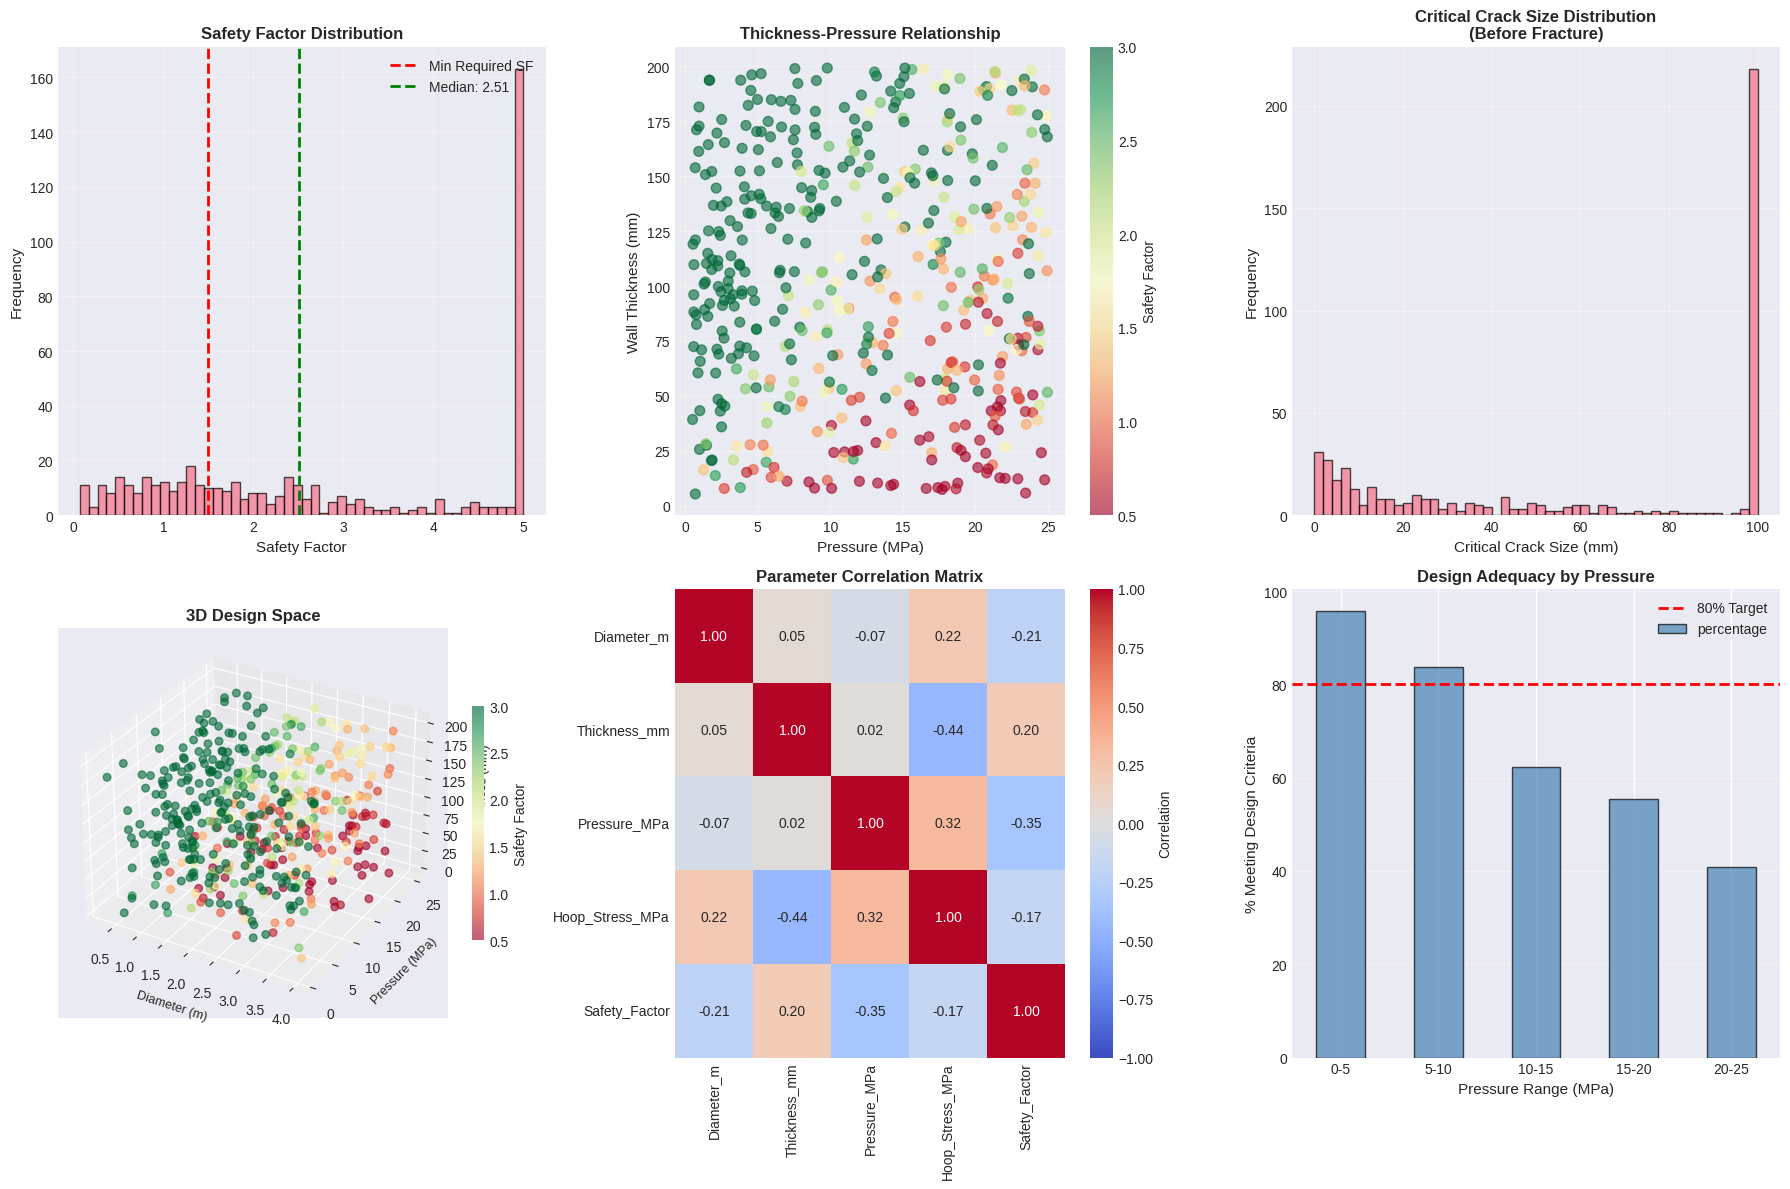


PRESSURE VESSEL DESIGN - STATISTICAL SUMMARY

Design Parameters:
       Diameter_m  Thickness_mm  Pressure_MPa  Hoop_Stress_MPa  Safety_Factor
count  500.000000    500.000000    500.000000       500.000000     500.000000
mean     2.129418    103.340193     12.558829       232.890820       6.938634
std      1.059295     55.390250      7.539108       451.707789      17.410079
min      0.300303      5.407921      0.502942         0.854531       0.072033
25%      1.252726     57.115835      5.614560        41.571045       1.255525
50%      2.079369    102.241225     12.549903       113.473507       2.510174
75%      2.999355    150.359800     19.302415       232.973585       7.027973
max      3.995998    199.192910     24.991284      4178.277225     313.162880



,Diameter_m,Thickness_mm,Pressure_MPa,Material_Yield_MPa,K_IC_MPa_m05,Hoop_Stress_MPa,Long_Stress_MPa,Von_Mises_MPa,Safety_Factor,Critical_Crack_mm,Design_Adequate,Pressure_Range
0,2.876936,46.502142,2.506414,222.840992,19.588974,77.531825,38.765913,67.144530,3.318826,20.319523,True,0-5
1,1.358716,81.499294,12.628471,247.344241,40.982622,105.267782,52.633891,91.164573,2.713162,48.245707,True,10-15
2,1.139350,171.051870,7.577807,257.888772,43.094215,25.237306,12.618653,21.856148,11.799370,928.115626,True,5-10
3,2.339865,29.884384,16.179801,269.261264,55.144079,633.416840,316.708420,548.555075,0.490855,2.412508,False,15-20
4,2.962035,179.303747,12.748431,166.574882,38.473922,105.299808,52.649904,91.192309,1.826633,42.494027,True,10-15
5,1.865494,101.819055,1.383099,262.102096,41.626980,12.670332,6.335166,10.972830,23.886463,3435.768593,True,0-5
6,3.928828,88.088653,8.306531,260.375403,48.764928,185.239103,92.619551,160.421769,1.623068,22.059718,True,5-10
7,2.833870,64.601046,12.481950,280.231847,39.699239,273.774396,136.887198,237.095582,1.181936,6.693123,False,10-15
8,2.079448,183.785513,14.518994,234.212080,55.142831,82.137850,41.068925,71.133465,3.292572,143.463554,True,10-15
9,1.750835,105.936575,3.069347,234.449404,46.868771,25.363851,12.681926,21.965740,10.673413,1086.893151,True,0-5


In [ ]:
# Comprehensive pressure vessel analysis
print("Analyzing Pressure Vessel Design Parameters...")

# Generate comprehensive dataset
n_vessels = 500
np.random.seed(123)

vessel_analysis = pd.DataFrame({
    'Diameter_m': np.random.uniform(0.3, 4.0, n_vessels),
    'Thickness_mm': np.random.uniform(5, 200, n_vessels),
    'Pressure_MPa': np.random.uniform(0.5, 25, n_vessels),
    'Material_Yield_MPa': np.random.normal(250, 30, n_vessels),
    'K_IC_MPa_m05': np.random.normal(50, 8, n_vessels)
})

# Calculate stresses
vessel_analysis['Hoop_Stress_MPa'] = (
    vessel_analysis['Pressure_MPa'] * vessel_analysis['Diameter_m'] * 1000 /
    (2 * vessel_analysis['Thickness_mm'])
)

vessel_analysis['Long_Stress_MPa'] = vessel_analysis['Hoop_Stress_MPa'] / 2

vessel_analysis['Von_Mises_MPa'] = np.sqrt(
    vessel_analysis['Hoop_Stress_MPa']**2 -
    vessel_analysis['Hoop_Stress_MPa'] * vessel_analysis['Long_Stress_MPa'] +
    vessel_analysis['Long_Stress_MPa']**2
)

# Safety factors
vessel_analysis['Safety_Factor'] = (
    vessel_analysis['Material_Yield_MPa'] / vessel_analysis['Von_Mises_MPa']
)

# Critical crack size
vessel_analysis['Critical_Crack_mm'] = (
    (vessel_analysis['K_IC_MPa_m05'] / vessel_analysis['Hoop_Stress_MPa'])**2 / np.pi * 1000
)

# Design adequacy
vessel_analysis['Design_Adequate'] = vessel_analysis['Safety_Factor'] >= 1.5

print(f"\n✓ Analyzed {len(vessel_analysis)} pressure vessels")
print(f"  {vessel_analysis['Design_Adequate'].sum()} vessels meet design criteria (SF ≥ 1.5)")
print(f"  {(~vessel_analysis['Design_Adequate']).sum()} vessels require redesign")

# Advanced visualization
fig = plt.figure(figsize=(18, 12))

# Plot 1: Safety factor distribution
ax1 = plt.subplot(2, 3, 1)
vessel_analysis['Safety_Factor'].clip(upper=5).hist(bins=50, alpha=0.7, edgecolor='black', ax=ax1)
plt.axvline(1.5, color='red', linestyle='--', linewidth=2, label='Min Required SF')
plt.axvline(vessel_analysis['Safety_Factor'].median(), color='green',
           linestyle='--', linewidth=2, label=f'Median: {vessel_analysis["Safety_Factor"].median():.2f}')
plt.xlabel('Safety Factor', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Safety Factor Distribution', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Thickness vs Pressure requirement
ax2 = plt.subplot(2, 3, 2)
scatter = plt.scatter(vessel_analysis['Pressure_MPa'],
                     vessel_analysis['Thickness_mm'],
                     c=vessel_analysis['Safety_Factor'],
                     cmap='RdYlGn', vmin=0.5, vmax=3, s=50, alpha=0.6)
plt.colorbar(scatter, label='Safety Factor')
plt.xlabel('Pressure (MPa)', fontsize=11)
plt.ylabel('Wall Thickness (mm)', fontsize=11)
plt.title('Thickness-Pressure Relationship', fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 3: Critical crack size distribution
ax3 = plt.subplot(2, 3, 3)
vessel_analysis['Critical_Crack_mm'].clip(upper=100).hist(
    bins=50, alpha=0.7, edgecolor='black', ax=ax3
)
plt.xlabel('Critical Crack Size (mm)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Critical Crack Size Distribution\n(Before Fracture)', fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 4: Multivariate analysis
ax4 = plt.subplot(2, 3, 4, projection='3d')
scatter = ax4.scatter(vessel_analysis['Diameter_m'],
                     vessel_analysis['Pressure_MPa'],
                     vessel_analysis['Thickness_mm'],
                     c=vessel_analysis['Safety_Factor'],
                     cmap='RdYlGn', vmin=0.5, vmax=3, s=30, alpha=0.6)
ax4.set_xlabel('Diameter (m)', fontsize=9)
ax4.set_ylabel('Pressure (MPa)', fontsize=9)
ax4.set_zlabel('Thickness (mm)', fontsize=9)
ax4.set_title('3D Design Space', fontweight='bold')
plt.colorbar(scatter, ax=ax4, shrink=0.5, label='Safety Factor')

# Plot 5: Covariance between parameters
ax5 = plt.subplot(2, 3, 5)
corr_params = vessel_analysis[['Diameter_m', 'Thickness_mm', 'Pressure_MPa',
                                'Hoop_Stress_MPa', 'Safety_Factor']].corr()
sns.heatmap(corr_params, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, vmin=-1, vmax=1, ax=ax5, cbar_kws={'label': 'Correlation'})
ax5.set_title('Parameter Correlation Matrix', fontweight='bold')

# Plot 6: Design adequacy by pressure range
ax6 = plt.subplot(2, 3, 6)
vessel_analysis['Pressure_Range'] = pd.cut(
    vessel_analysis['Pressure_MPa'],
    bins=[0, 5, 10, 15, 20, 25],
    labels=['0-5', '5-10', '10-15', '15-20', '20-25']
)
adequacy_by_pressure = vessel_analysis.groupby('Pressure_Range')['Design_Adequate'].agg(['sum', 'count'])
adequacy_by_pressure['percentage'] = (adequacy_by_pressure['sum'] / adequacy_by_pressure['count']) * 100

adequacy_by_pressure['percentage'].plot(kind='bar', ax=ax6, color='steelblue',
                                        alpha=0.7, edgecolor='black')
plt.axhline(80, color='red', linestyle='--', linewidth=2, label='80% Target')
plt.xlabel('Pressure Range (MPa)', fontsize=11)
plt.ylabel('% Meeting Design Criteria', fontsize=11)
plt.title('Design Adequacy by Pressure', fontweight='bold')
plt.xticks(rotation=0)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Export summary statistics
print("\n" + "="*60)
print("PRESSURE VESSEL DESIGN - STATISTICAL SUMMARY")
print("="*60)
print("\nDesign Parameters:")
print(vessel_analysis[['Diameter_m', 'Thickness_mm', 'Pressure_MPa',
                       'Hoop_Stress_MPa', 'Safety_Factor']].describe())

print("\n" + "="*60)
display(vessel_analysis.head(10))

## 9. Industrial Failure Case Studies


INDUSTRIAL FAILURE CASE STUDIES

Case 1: Pacific Pipeline LA
------------------------------------------------------------
  Component: Trunnion Ball Valve
  Failure_Mode: Fatigue - 8 bolts
  Pressure_psi: 744.0
  Pressure_MPa: 5.12970144
  Elevation_ft: 468.0
  API_Gravity: 14.3
  Year: 2024

Case 2: BC Energy Well
------------------------------------------------------------
  Component: Production Well
  Failure_Mode: Well Failure
  Year: 2024
  Depth_m: 4148.3
  H2S_Start_ppm: 8300.0
  H2S_Failure_ppm: 6200.0
  H2S_Reduction_ppm: 2100.0


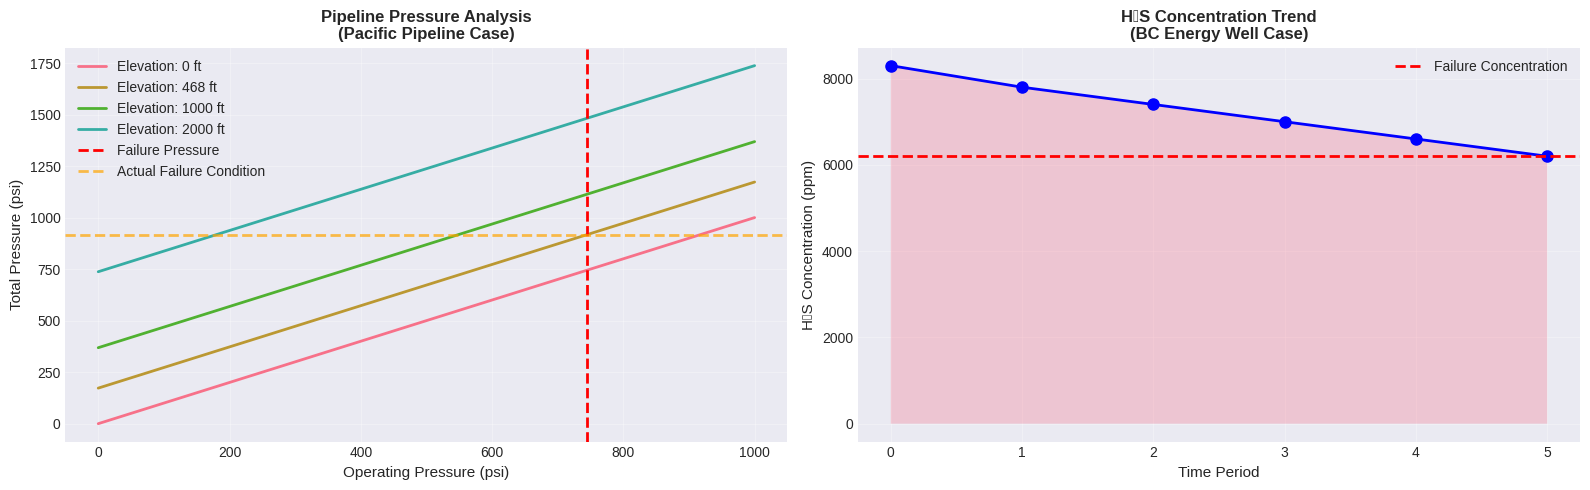

In [ ]:
# Industrial failure database
failure_cases = pd.DataFrame([
    {
        'Case': 'Pacific Pipeline LA',
        'Component': 'Trunnion Ball Valve',
        'Failure_Mode': 'Fatigue - 8 bolts',
        'Pressure_psi': 744,
        'Pressure_MPa': 744 * 0.00689476,
        'Elevation_ft': 468,
        'API_Gravity': 14.3,
        'Year': 2024
    },
    {
        'Case': 'BC Energy Well',
        'Component': 'Production Well',
        'Failure_Mode': 'Well Failure',
        'Depth_m': 4148.3,
        'H2S_Start_ppm': 8300,
        'H2S_Failure_ppm': 6200,
        'H2S_Reduction_ppm': 2100,
        'Year': 2024
    }
])

print("\n" + "="*60)
print("INDUSTRIAL FAILURE CASE STUDIES")
print("="*60)

for idx, case in failure_cases.iterrows():
    print(f"\nCase {idx + 1}: {case['Case']}")
    print("-" * 60)
    for key, value in case.items():
        if pd.notna(value) and key != 'Case':
            print(f"  {key}: {value}")

# Visualize failure data
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Pipeline pressure analysis
pressures = np.linspace(0, 1000, 100)  # psi
elevations = np.array([0, 468, 1000, 2000])  # ft

ax = axes[0]
for elev in elevations:
    # Hydrostatic pressure correction
    rho = 850  # kg/m³ for crude oil (API 14.3)
    g = 9.81  # m/s²
    elev_m = elev * 0.3048  # ft to m
    hydrostatic_Pa = rho * g * elev_m
    hydrostatic_psi = hydrostatic_Pa / 6894.76

    total_pressure = pressures + hydrostatic_psi
    ax.plot(pressures, total_pressure, linewidth=2, label=f'Elevation: {elev} ft')

ax.axvline(744, color='red', linestyle='--', linewidth=2, label='Failure Pressure')
ax.axhline(744 + (468 * 0.3048 * 850 * 9.81 / 6894.76), color='orange',
          linestyle='--', linewidth=2, alpha=0.7, label='Actual Failure Condition')
ax.set_xlabel('Operating Pressure (psi)', fontsize=11)
ax.set_ylabel('Total Pressure (psi)', fontsize=11)
ax.set_title('Pipeline Pressure Analysis\n(Pacific Pipeline Case)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: H2S concentration over time
ax = axes[1]
time_points = np.array([0, 1, 2, 3, 4, 5])  # Arbitrary time units
h2s_concentration = np.array([8300, 7800, 7400, 7000, 6600, 6200])

ax.plot(time_points, h2s_concentration, 'bo-', linewidth=2, markersize=8)
ax.axhline(6200, color='red', linestyle='--', linewidth=2, label='Failure Concentration')
ax.fill_between(time_points, 0, h2s_concentration, alpha=0.3)
ax.set_xlabel('Time Period', fontsize=11)
ax.set_ylabel('H₂S Concentration (ppm)', fontsize=11)
ax.set_title('H₂S Concentration Trend\n(BC Energy Well Case)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary and Export Results

In [ ]:
# Create comprehensive summary
summary_stats = {
    'Analysis': [
        'Griffith Crack Theory',
        'Irwin Stress Intensity',
        'Paris-Erdogan Fatigue',
        'Von Mises vs Tresca',
        'Pressure Vessel Design'
    ],
    'Samples': [
        len(griffith_results),
        len(irwin_results),
        len(paris_results),
        len(failure_results),
        len(vessel_analysis)
    ],
    'Key_Finding': [
        f'Breaking strength inversely proportional to √crack_size',
        f'Max force for 24mm crack: {critical_crack_data["Max_Force_kN"].mean():.1f} kN',
        f'Max stress for ≤5% growth: {max_allowable_stress:.1f} MPa',
        f'Tresca {failure_results["Difference_Pct"].mean():.1f}% more conservative',
        f'{vessel_analysis["Design_Adequate"].sum()}/{len(vessel_analysis)} vessels adequate'
    ]
}

summary_df = pd.DataFrame(summary_stats)

print("\n" + "="*80)
print(" " * 20 + "ANALYSIS SUMMARY")
print("="*80)
display(summary_df)

# Export data to CSV (optional)
export_data = True

if export_data:
    print("\nExporting datasets to CSV files...")
    material_data.to_csv('material_properties.csv', index=False)
    griffith_results.to_csv('griffith_analysis.csv', index=False)
    irwin_results.to_csv('irwin_analysis.csv', index=False)
    paris_results.to_csv('paris_analysis.csv', index=False)
    failure_results.to_csv('failure_criteria.csv', index=False)
    vessel_analysis.to_csv('vessel_analysis.csv', index=False)
    print("✓ All datasets exported successfully")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\nAll engineering failure prediction theorems have been analyzed with:")
print("  ✓ Data ranges and statistical distributions")
print("  ✓ Covariance analysis between material properties")
print("  ✓ Comprehensive trend visualizations")
print("  ✓ Industrial case study data")
print("  ✓ Statistical summaries and insights")
print("\nReferences:")
print("  - ASME Boiler and Pressure Vessel Code")
print("  - AASHTO LRFD Bridge Design Specifications")
print("  - FAA Advisory Circular AC 33.14-1")
print("  - PHMSA Pipeline Safety Regulations")
print("  - BC Energy Regulator Standards")


                    ANALYSIS SUMMARY


,Analysis,Samples,Key_Finding
0,Griffith Crack Theory,5000,Breaking strength inversely proportional to √c...
1,Irwin Stress Intensity,5000,Max force for 24mm crack: 800.1 kN
2,Paris-Erdogan Fatigue,30,Max stress for ≤5% growth: 20.0 MPa
3,Von Mises vs Tresca,200,Tresca 15.4% more conservative
4,Pressure Vessel Design,500,339/500 vessels adequate



Exporting datasets to CSV files...
✓ All datasets exported successfully

ANALYSIS COMPLETE

All engineering failure prediction theorems have been analyzed with:
  ✓ Data ranges and statistical distributions
  ✓ Covariance analysis between material properties
  ✓ Comprehensive trend visualizations
  ✓ Industrial case study data
  ✓ Statistical summaries and insights

References:
  - ASME Boiler and Pressure Vessel Code
  - AASHTO LRFD Bridge Design Specifications
  - FAA Advisory Circular AC 33.14-1
  - PHMSA Pipeline Safety Regulations
  - BC Energy Regulator Standards


In [ ]:
display(summary_df)

,Analysis,Samples,Key_Finding
0,Griffith Crack Theory,5000,Breaking strength inversely proportional to √c...
1,Irwin Stress Intensity,5000,Max force for 24mm crack: 800.1 kN
2,Paris-Erdogan Fatigue,30,Max stress for ≤5% growth: 20.0 MPa
3,Von Mises vs Tresca,200,Tresca 15.4% more conservative
4,Pressure Vessel Design,500,339/500 vessels adequate
